# Exploratory Data Analysis (EDA)

This notebook explores:
- Price trends
- Seasonality
- County distributions
- Missing values

Importing the neccessary files usnig the right path to explore the dataset.

In [ ]:
#import the neccessary file and set the path

import sys
PATH_PROJECT=""
sys.path.insert(0, PROJECT_PATH)



**agriBORA PRICE TREND BY COUNTY**

Price trend visualization helps us understand how maize prices change over time across different counties. It reveals long-term movements such as increasing or decreasing prices and helps detect overall market behavior, which is essential for time-series forecasting.

This visualization helps identify long-term maize price movement patterns across counties. It allows us to observe periods of price increases, declines, volatility, and market stability over time.


**NOTE:**

Cleaned agriBORA dataset which is used in the visualization in each county.

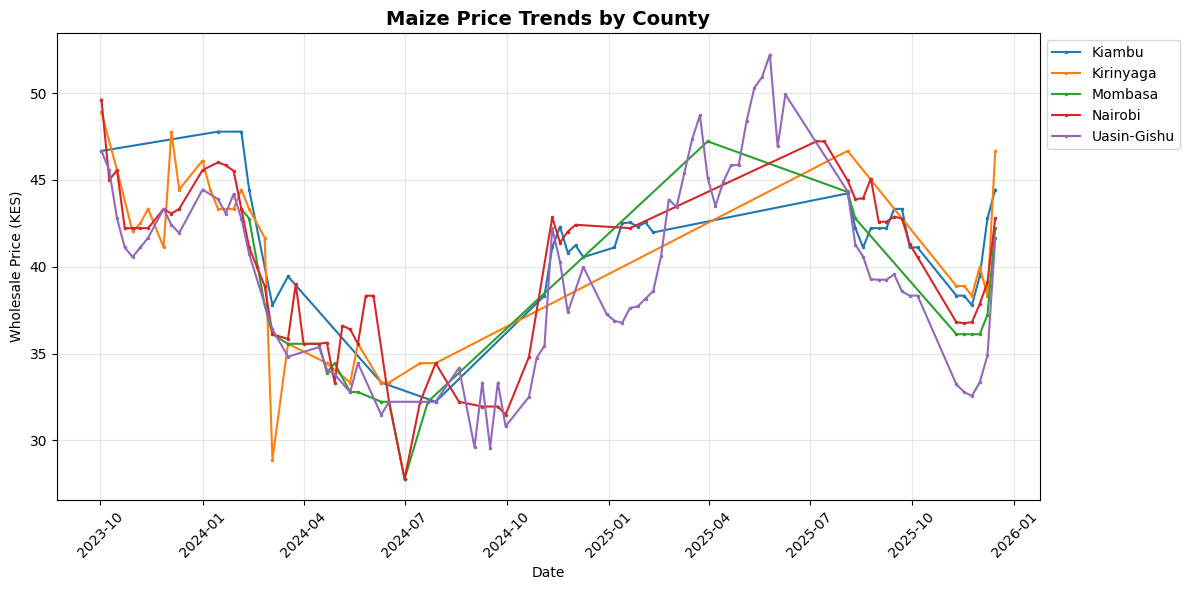

In [ ]:

# PRICE TRENDS


eda.plot_price_trends(df)

**Price distribution**

This boxplot helps compare price spread and variability across counties. It also helps identify counties with higher volatility and potential outliers in trhe dataset.

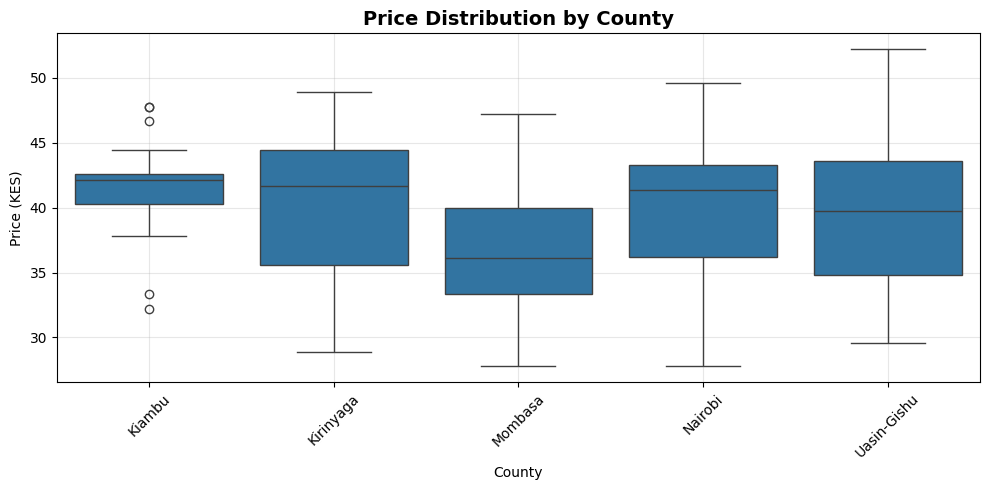

In [ ]:
plot_price_distribution(df)


**Weekly Seasonality**

This visualization helps identify seasonal price behavior across weeks of the year. It helps determine whether maize prices follow recurring seasonal patterns.

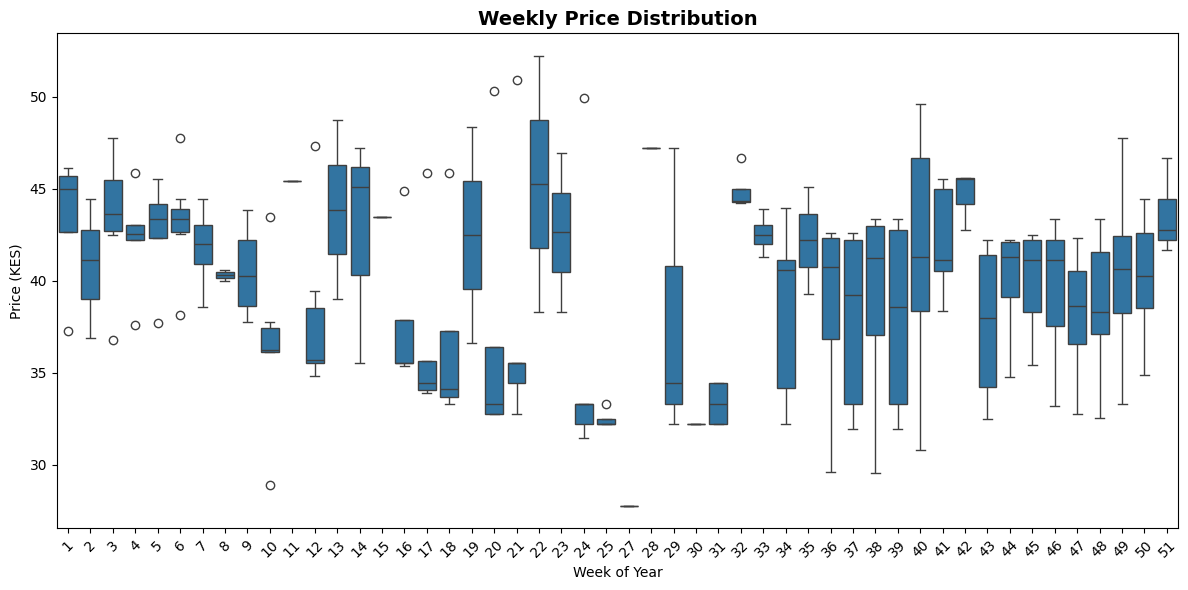

In [ ]:

# WEEKLY SEASONALITY


eda.plot_weekly_seasonality(df)

In [ ]:
plot_monthly_boxplot_by_county(df)

Kamis data followed similar market trends to AgriBORA prices, showing moderate to strong correlation across counties. However, the absolute price values differed significantly, resulting in high MAE and RMSE values. This indicates that Kamis data captures general price direction but is unreliable for precise forecasting. Therefore, AgriBORA data was prioritized for final model training.


In [ ]:
# ============================================
# CLEAN DATA
# ============================================

kamis_clean=clean_kamis_data(
    data['kamis'],
    target_counties
)

display(
    kamis_clean.head()
)

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear
5512,Kirinyaga,2022-01-03,37.78,Dry_White_Maize,2022-01,1
5513,Kirinyaga,2022-01-03,30.00,Dry_White_Maize,2022-01,1
5529,Kirinyaga,2022-01-04,33.33,Dry_White_Maize,2022-01,1
5537,Nairobi,2022-01-04,38.00,Dry_White_Maize,2022-01,1
5557,Uasin-Gishu,2022-01-05,24.00,Dry_White_Maize,2022-01,1


In [ ]:
kamis_clean.duplicated().sum()

np.int64(0)

**Visualize the kamis clean data price change overtime**


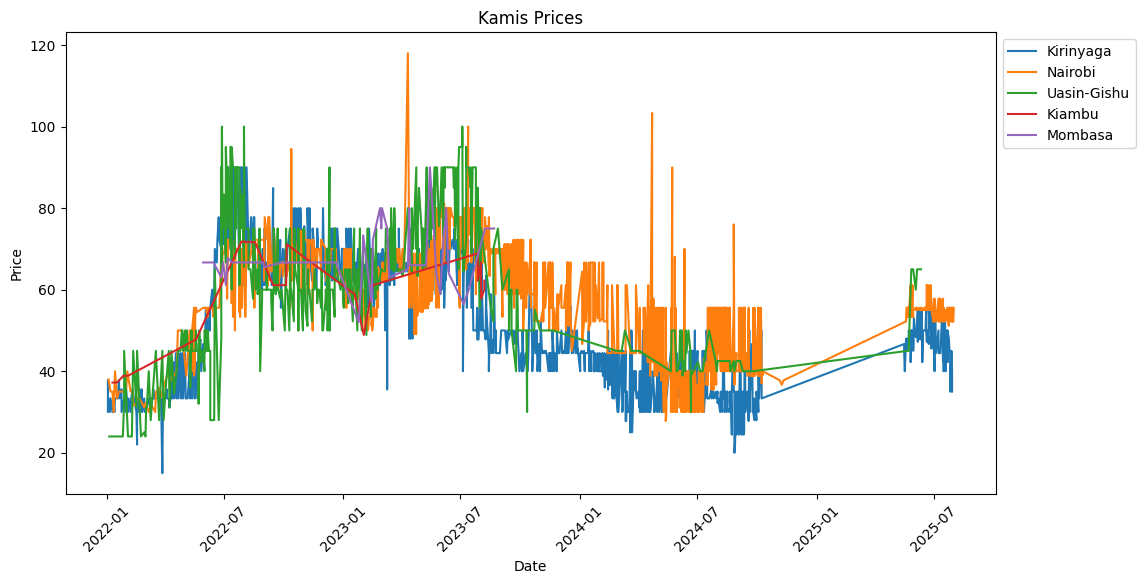

In [ ]:

plt.figure(figsize=(12,6))
for county in kamis_clean['County'].unique():
    data = kamis_clean[kamis_clean['County'] == county]
    plt.plot(data['Date'], data['WholeSale'], label=county)

plt.title("Kamis Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.show()

PRICE DISTRIBUTIION PER COUNTY

Observations: Wide ranges (big spread between min and max) Presence of outliers.

Some counties have very extreme values

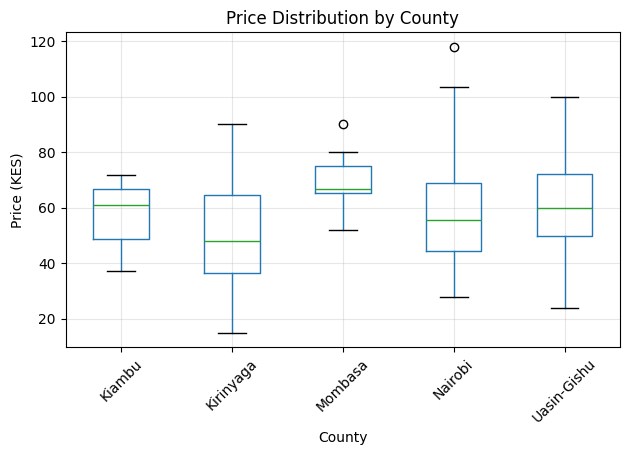

In [ ]:
kamis_clean.boxplot( column='WholeSale', by='County')

plt.title("Price Distribution by County")
plt.suptitle("")
plt.xlabel("County")
plt.ylabel("Price (KES)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

**Average price per county**

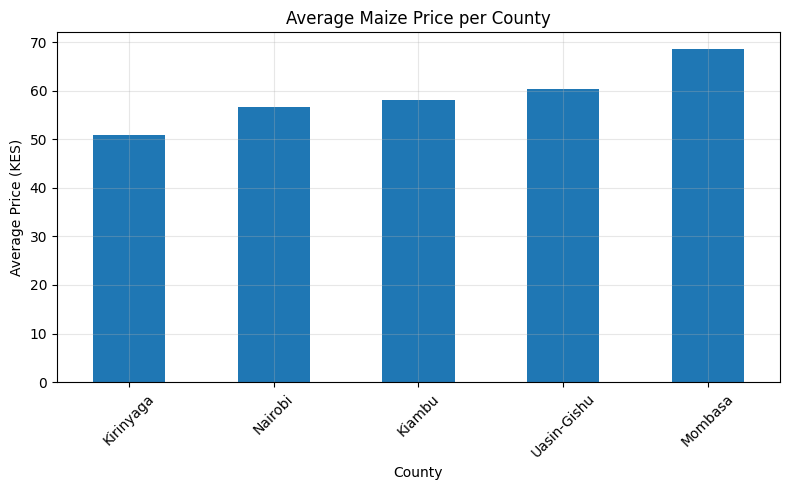

In [ ]:
avg_price = kamis_clean.groupby('County')['WholeSale'].mean().sort_values()

avg_price.plot(kind='bar', figsize=(8,5))

plt.title("Average Maize Price per County")
plt.ylabel("Average Price (KES)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CHECK DATA STRUCTURE
# =========================================================

print("AgriBORA")
display(agri_clean.head())

print("\nKamis")
display(kamis_clean.head())

print("\nKamis Raw")
display(kamis_raw_clean.head())

AgriBORA


,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear
0,Kiambu,2023-10-02,46.67,Dry_White_Maize,2023-40,40
1,Kiambu,2024-01-15,47.78,Dry_White_Maize,2024-03,3
2,Kiambu,2024-02-05,47.78,Dry_White_Maize,2024-06,6
3,Kiambu,2024-02-12,44.44,Dry_White_Maize,2024-07,7
4,Kiambu,2024-03-04,37.78,Dry_White_Maize,2024-10,10



Kamis


,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear
5512,Kirinyaga,2022-01-03,37.78,Dry_White_Maize,2022-01,1
5513,Kirinyaga,2022-01-03,30.00,Dry_White_Maize,2022-01,1
5529,Kirinyaga,2022-01-04,33.33,Dry_White_Maize,2022-01,1
5537,Nairobi,2022-01-04,38.00,Dry_White_Maize,2022-01,1
5557,Uasin-Gishu,2022-01-05,24.00,Dry_White_Maize,2022-01,1



Kamis Raw


,County,Date,WholeSale,Commodity_Classification,Year,WeekofYear,Year_Week
0,Nairobi,2025-07-31,55.00,Dry_White_Maize,2025,31,2025_31
14,Nairobi,2025-07-30,55.56,Dry_White_Maize,2025,31,2025_31
23,Kirinyaga,2025-07-29,40.00,Dry_White_Maize,2025,31,2025_31
36,Nairobi,2025-07-29,55.00,Dry_White_Maize,2025,31,2025_31
44,Kirinyaga,2025-07-28,45.00,Dry_White_Maize,2025,31,2025_31


**Checking the kamis_raw data**

In [ ]:
kamis_raw_clean.head()

,County,Date,WholeSale,Commodity_Classification,Year,WeekofYear,Year_Week
0,Nairobi,2025-07-31,55.00,Dry_White_Maize,2025,31,2025_31
14,Nairobi,2025-07-30,55.56,Dry_White_Maize,2025,31,2025_31
23,Kirinyaga,2025-07-29,40.00,Dry_White_Maize,2025,31,2025_31
36,Nairobi,2025-07-29,55.00,Dry_White_Maize,2025,31,2025_31
44,Kirinyaga,2025-07-28,45.00,Dry_White_Maize,2025,31,2025_31


In [ ]:
print(f" Final: {kamis_raw_clean.shape}")

 Final: (1765, 6)


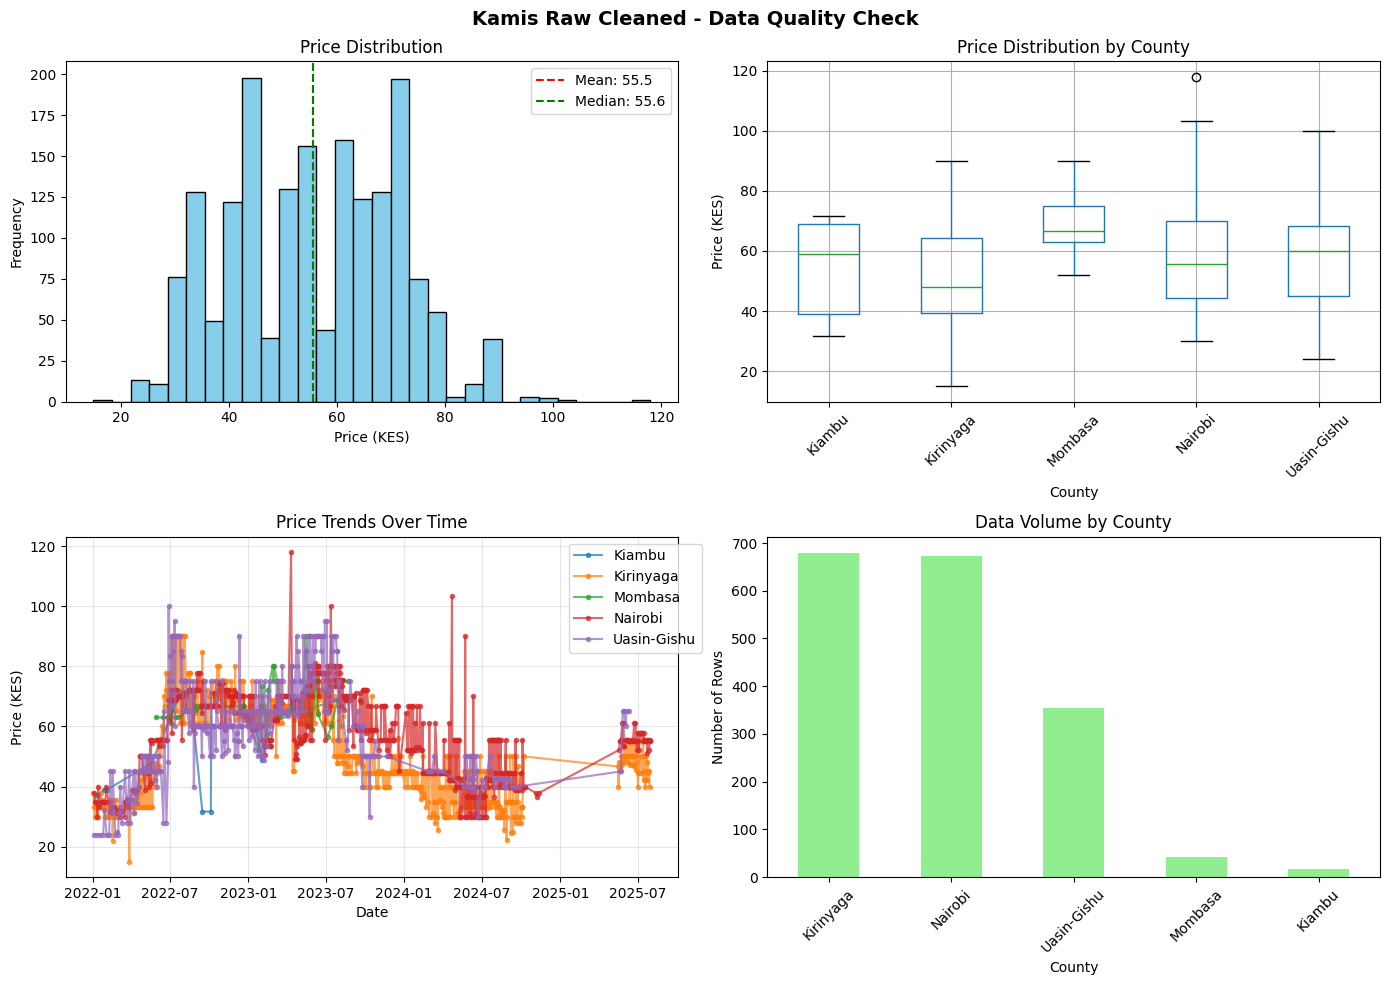

In [ ]:
# Cell: Visualize data quality

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Price distribution
axes[0,0].hist(kamis_raw_clean['WholeSale'], bins=30, color='skyblue', edgecolor='black')
axes[0,0].axvline(kamis_raw_clean['WholeSale'].mean(), color='red', linestyle='--', label=f"Mean: {kamis_raw_clean['WholeSale'].mean():.1f}")
axes[0,0].axvline(kamis_raw_clean['WholeSale'].median(), color='green', linestyle='--', label=f"Median: {kamis_raw_clean['WholeSale'].median():.1f}")
axes[0,0].set_xlabel('Price (KES)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Price Distribution')
axes[0,0].legend()

# Plot 2: Boxplot by county
kamis_raw_clean.boxplot(column='WholeSale', by='County', ax=axes[0,1])
axes[0,1].set_title('Price Distribution by County')
axes[0,1].set_xlabel('County')
axes[0,1].set_ylabel('Price (KES)')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Time series by county
for county in target_counties:
    data = kamis_raw_clean[kamis_raw_clean['County'] == county].sort_values('Date')
    if len(data) > 0:
        axes[1,0].plot(data['Date'], data['WholeSale'], marker='.', label=county, alpha=0.7)
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Price (KES)')
axes[1,0].set_title('Price Trends Over Time')
axes[1,0].legend(bbox_to_anchor=(1.05, 1))
axes[1,0].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)


# Plot 4: Rows per county
county_counts = kamis_raw_clean['County'].value_counts()
county_counts.plot(kind='bar', ax=axes[1,1], color='lightgreen')
axes[1,1].set_xlabel('County')
axes[1,1].set_ylabel('Number of Rows')
axes[1,1].set_title('Data Volume by County')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Kamis Raw Cleaned - Data Quality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# MERGE DATASETS FOR COMPARISON
# =========================================================

county = "Nairobi"


# Kamis
kamis = kamis_clean[
    kamis_clean['County'] == county
][['Date', 'WholeSale']]

kamis = kamis.rename(
    columns={'WholeSale': 'kamis_price'}
)

# Kamis Raw
raw = kamis_raw_clean[
    kamis_raw_clean['County'] == county
][['Date', 'WholeSale']]

raw = raw.rename(
    columns={'WholeSale': 'raw_price'}
)

# Merge datasets
merged = pd.merge(
    df,
    kamis,
    on='Date',
    how='inner'
)

merged = pd.merge(
    merged,
    raw,
    on='Date',
    how='inner'
)

print("Merged Dataset Shape:", merged.shape)

display(merged.head())

Merged Dataset Shape: (217, 5)


,County,Date,WholeSale,kamis_price,raw_price
0,Kiambu,2023-10-02,46.67,72.22,72.22
1,Kiambu,2023-10-02,46.67,58.89,72.22
2,Kiambu,2024-01-15,47.78,66.67,66.67
3,Kiambu,2024-01-15,47.78,52.22,66.67
4,Kiambu,2024-01-15,47.78,50.00,66.67


##**Correlation analysis**

Correlation values between AgriBORA and Kamis range approximately between 0.5-0.65, showing moderate positive relationships.

This indicates that both datasets generally move in the same direction over time. However, mean price differences are consistently large (10-32 KES), suggesting Kamis prices systematically differ from AgriBORA values.

Therefore Kamis captures market trends reasonably well but may introduce bias if used directly for prediction without normalization or adjustment.

In [ ]:
# =========================================================
# CORRELATION CALCULATION
# =========================================================

corr_kamis = merged['WholeSale'].corr(
    merged['kamis_price']
)

corr_raw = merged['WholeSale'].corr(
    merged['raw_price']
)

print("=" * 60)
print("CORRELATION RESULTS")
print("=" * 60)

print(f"AgriBORA vs Kamis Correlation: {corr_kamis:.4f}")
print(f"AgriBORA vs Kamis Raw Correlation: {corr_raw:.4f}")

CORRELATION RESULTS
AgriBORA vs Kamis Correlation: 0.4984
AgriBORA vs Kamis Raw Correlation: 0.4563


The correlation analysis was conducted to evaluate how closely AgriBORA maize prices align with KAMIS market prices across counties. The analysis uses only overlapping dates shared between datasets to ensure fair comparison.

The correlation values indicate that the datasets generally move in similar directions over time, although the exact price values may differ. MAE and RMSE were used to measure the average magnitude of price differences, while R² was used to evaluate predictive alignment between sources.

Some counties showed “Not enough overlap” because the datasets did not contain enough shared dates after merging. This highlights data availability limitations rather than preprocessing errors.

Overall, the analysis helps assess the reliability and consistency of AgriBORA prices against external market references before model training.


In [ ]:
# ============================================
# CORRELATION ANALYSIS
# ============================================


correlation_results=correlation_analysis(

    agri_clean,
    kamis_clean,
    kamis_raw_clean,
    target_counties
)

display(
    correlation_results
)

CORRELATION ANALYSIS
Kiambu: Not enough overlap
Mombasa: Not enough overlap


,County,Correlation_Kamis,Correlation_Raw,MAE,RMSE,R2,Rows
0,Kirinyaga,0.572,0.809,3.85,5.36,-0.627,19
1,Nairobi,0.513,0.503,11.62,15.19,-7.020,73
2,Uasin-Gishu,0.640,0.640,9.66,10.63,-2.459,6


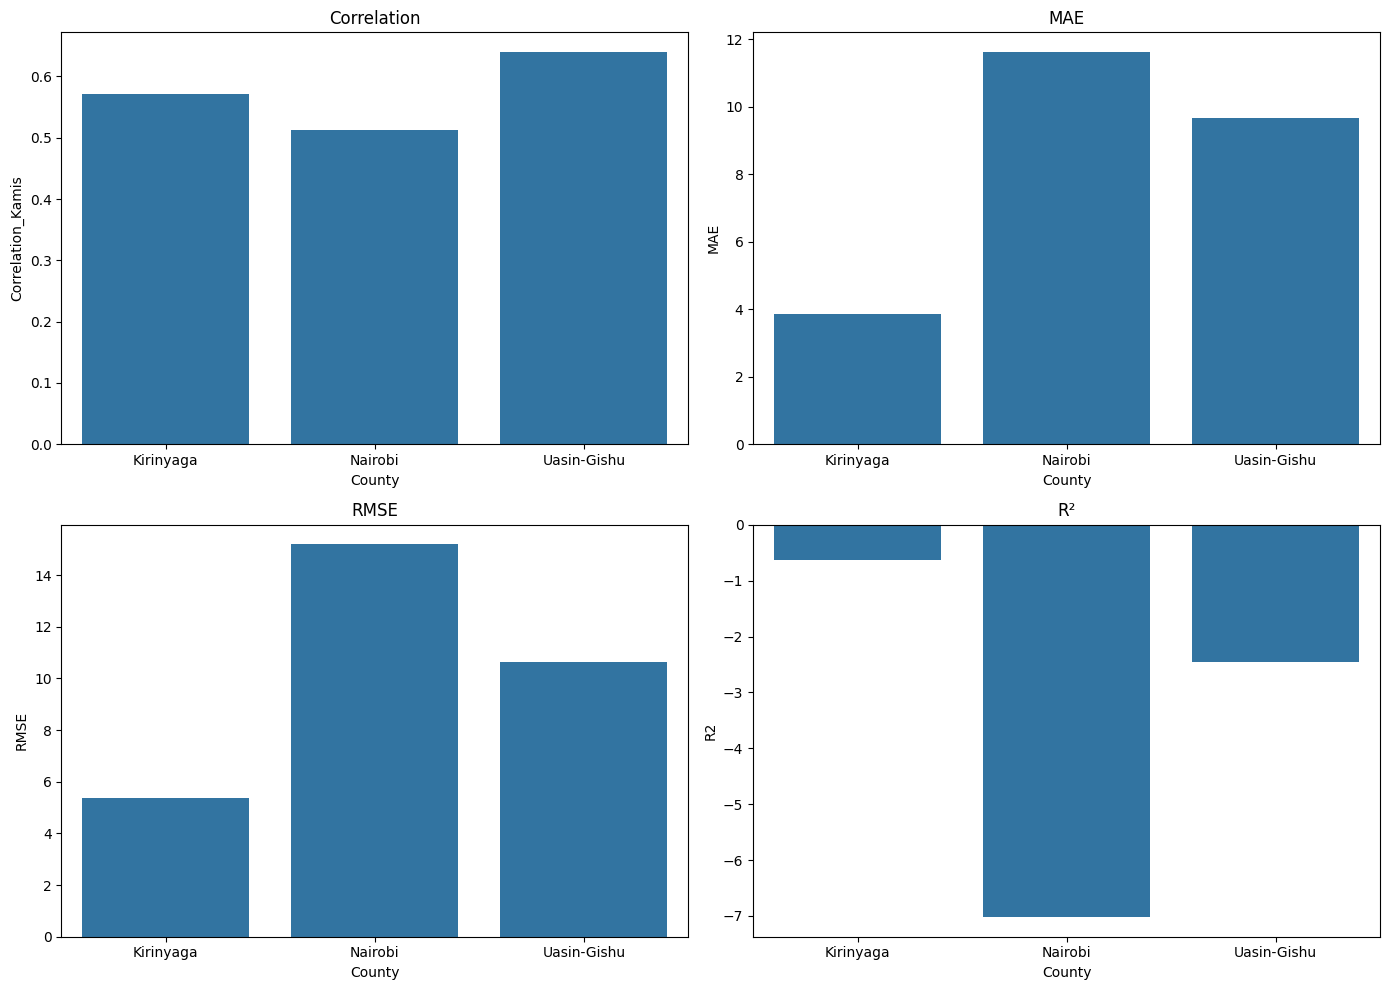

In [ ]:

# VISUALIZE CORRELATION RESULTS


plot_correlation_results(correlation_results)

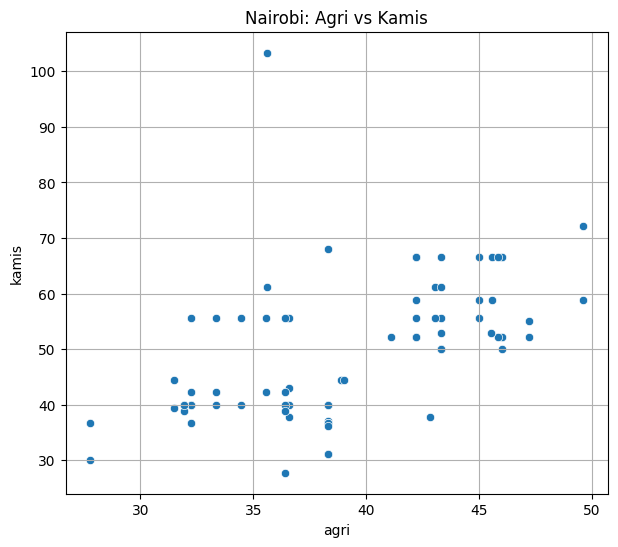

In [ ]:

# SCATTER PLOT COMPARISON

plot_scatter_comparison(
    agri_clean,
    kamis_clean,
    county='Nairobi'
)


**Key observations**

NOT ENOUGH OVERLAPING IN KIAMBU AND MOMBASA

This means:

AgriBORA and KAMIS datasets do not share enough common dates.

After merging on date, too few rows remained.

NOTE:
Statistically comparing this two counties is very weak.

| County      | Rows |
| ----------- | ---- |
| Kirinyaga   | 19   |
| Uasin-Gishu | 6    |
